##Step 1


/tmp/ipython-input-640912082.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


=== First 5 rows of NVDA data ===
Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.971077  5.971077  5.891683  5.942207  237536000
2020-01-03  5.875505  5.919309  5.826474  5.851363  205384000
2020-01-06  5.900144  5.905370  5.756038  5.782171  262636000
2020-01-07  5.971575  6.017370  5.883468  5.928517  314856000
2020-01-08  5.982774  6.024089  5.927272  5.967343  277108000

=== Last 5 rows of NVDA data ===
Price            Close        High         Low        Open     Volume
Ticker            NVDA        NVDA        NVDA        NVDA       NVDA
Date                                                                 
2024-12-23  139.631790  139.751752  135.083032  136.242718  176053500
2024-12-24  140.181656  141.861189  138.612078  139.961715  105157000
2024-12-26  139.891724  140.811485  137.692328  139.661791  116205600
2024-12-27  136.

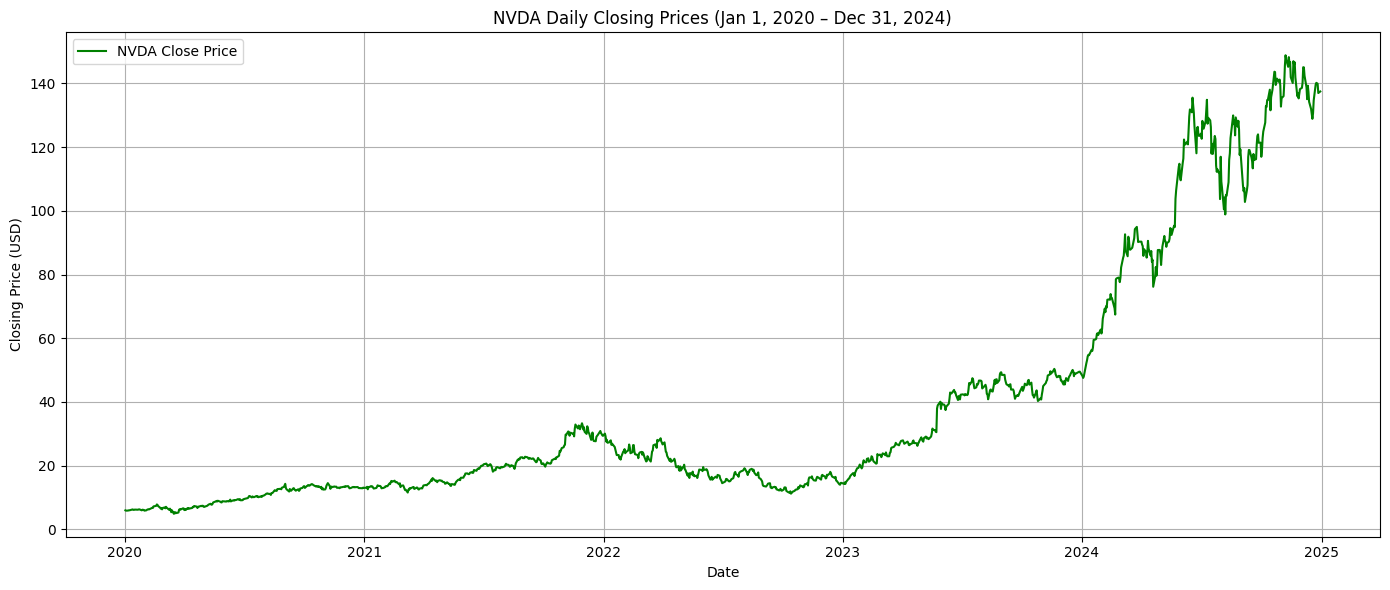

Saved data to 'NVDA_2020_2024.csv'


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1) Fetch NVDA daily historical data from Jan 1, 2020 to Dec 31, 2024
# -----------------------------------------------------------------------------
ticker = "NVDA"
start_date = "2020-01-01"
end_date = "2024-12-31"

# Download data
data = yf.download(ticker, start=start_date, end=end_date)

# -----------------------------------------------------------------------------
# 2) Inspect the dataset (first & last few rows)
# -----------------------------------------------------------------------------
print("=== First 5 rows of NVDA data ===")
print(data.head())
print("\n=== Last 5 rows of NVDA data ===")
print(data.tail())

# -----------------------------------------------------------------------------
# 3) Plot daily closing price over time
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], color='green', label='NVDA Close Price')
plt.title('NVDA Daily Closing Prices (Jan 1, 2020 – Dec 31, 2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4) Optional: Save full dataset to CSV
# -----------------------------------------------------------------------------
output_filename = "NVDA_2020_2024.csv"
data.to_csv(output_filename)
print(f"Saved data to '{output_filename}'")


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


In [3]:
data = yf.download("NVDA", start="2020-01-01", end="2024-12-31")

# Log returns
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))
data.dropna(inplace=True)


/tmp/ipython-input-235632123.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NVDA", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [4]:
k = 5  # window size

data["leaky_label"] = (
    data["log_return"]
    .rolling(window=2*k+1, center=True)
    .mean()
)

data.dropna(inplace=True)


In [5]:
data["ret_lag1"] = data["log_return"].shift(1)
data["ret_lag2"] = data["log_return"].shift(2)
data["ret_lag3"] = data["log_return"].shift(3)

data.dropna(inplace=True)

X = data[["ret_lag1", "ret_lag2", "ret_lag3"]]
y = data["leaky_label"]


In [6]:
split_date = "2023-01-01"

X_train = X.loc[:split_date]
X_test  = X.loc[split_date:]

y_train = y.loc[:split_date]
y_test  = y.loc[split_date:]


In [7]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=6, n_estimators=300, random_state=42)

In [8]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test  R²:", r2_score(y_test, test_pred))


Train R²: 0.5309280099934965
Test  R²: 0.11391720311702502


In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Select lagged return features (causal-looking but labels are not)
X = data[[
    "ret_lag1",
    "ret_lag2",
    "ret_lag3"
]]

# Leaky target variable
y = data["leaky_label"]

# Single time-based split
split_date = "2023-01-01"

X_train = X.loc[:split_date]
X_test  = X.loc[split_date:]

y_train = y.loc[:split_date]
y_test  = y.loc[split_date:]

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        max_iter=2000,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)

# Predictions
train_pred = mlp_pipeline.predict(X_train)
test_pred  = mlp_pipeline.predict(X_test)

# Performance metrics
train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)

train_mse = mean_squared_error(y_train, train_pred)
test_mse  = mean_squared_error(y_test, test_pred)

print("MLP Train R²:", train_r2)
print("MLP Test  R²:", test_r2)
print("MLP Train MSE:", train_mse)
print("MLP Test  MSE:", test_mse)


MLP Train R²: -6.125267426761353
MLP Test  R²: -8.0574462852766
MLP Train MSE: 0.0007004983421367735
MLP Test  MSE: 0.0007186821431314641


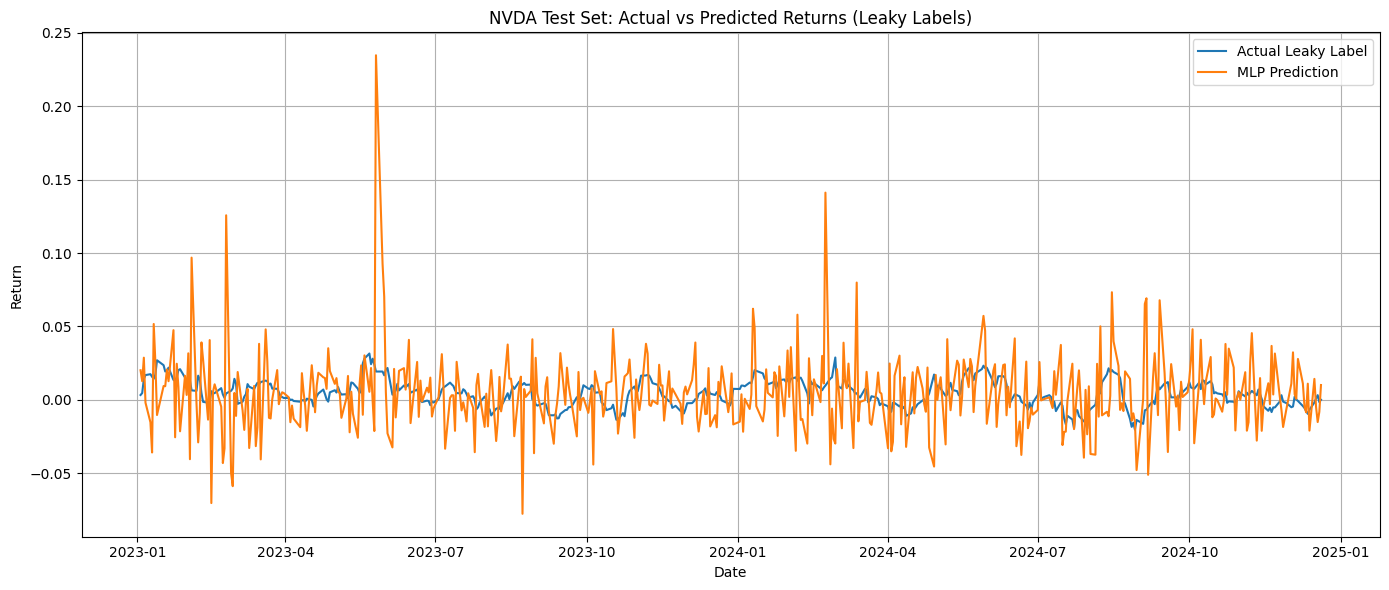

In [10]:
import matplotlib.pyplot as plt

# Convert predictions to pandas Series for alignment
y_test_pred = pd.Series(
    test_pred,
    index=y_test.index
)

# Plot actual vs predicted leaky labels
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual Leaky Label")
plt.plot(y_test_pred.index, y_test_pred, label="MLP Prediction")
plt.title("NVDA Test Set: Actual vs Predicted Returns (Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.7827e-04 - val_loss: 8.3860e-05
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.0021e-05 - val_loss: 9.8434e-05
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0343e-04 - val_loss: 1.0151e-04
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0754e-04 - val_loss: 8.7565e-05
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0211e-04 - val_loss: 7.5444e-05
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.3245e-05 - val_loss: 7.0537e-05
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.6316e-05 - val_loss: 6.8846e-05
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.2240e-05 - val_loss: 6.8645e-05
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.0703e-05 - val_loss: 6.8737e-05
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.0366e-05 - val_loss: 6.8700e-05
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.0107e-05 - 

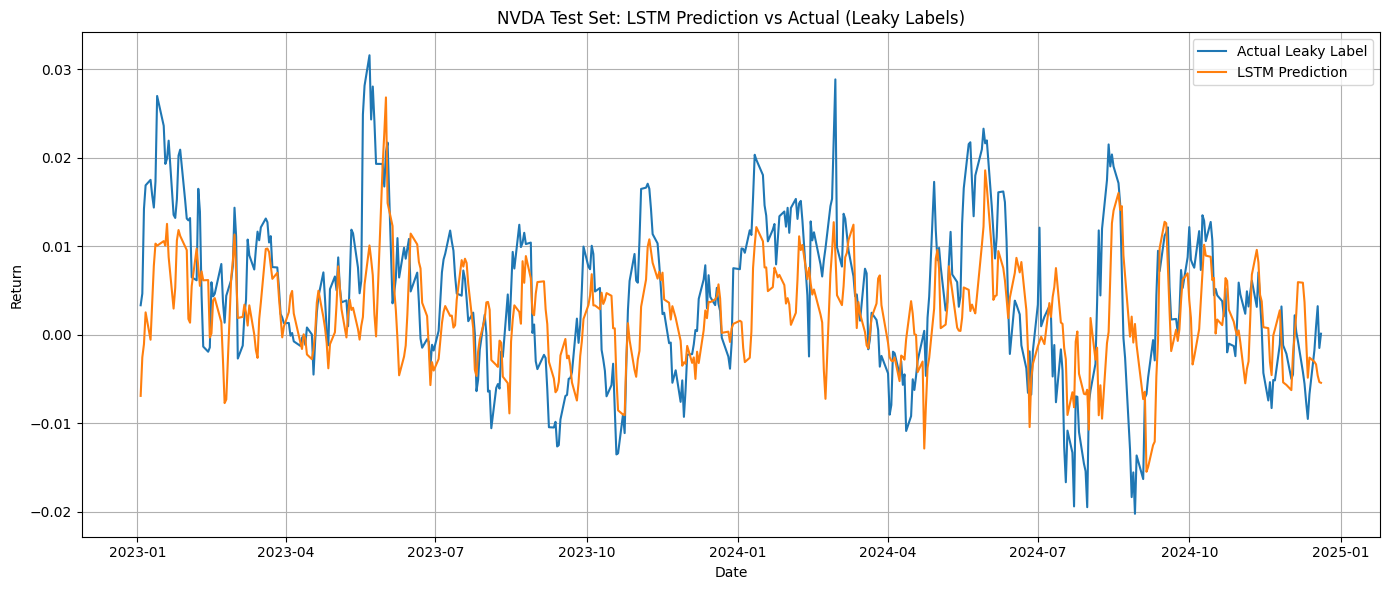

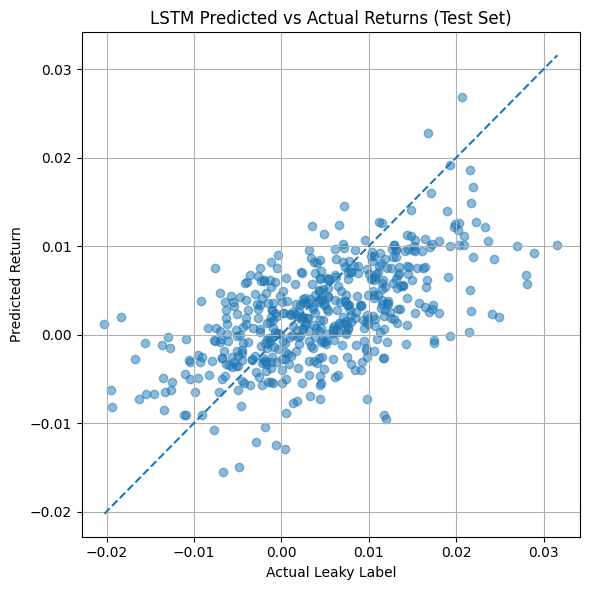

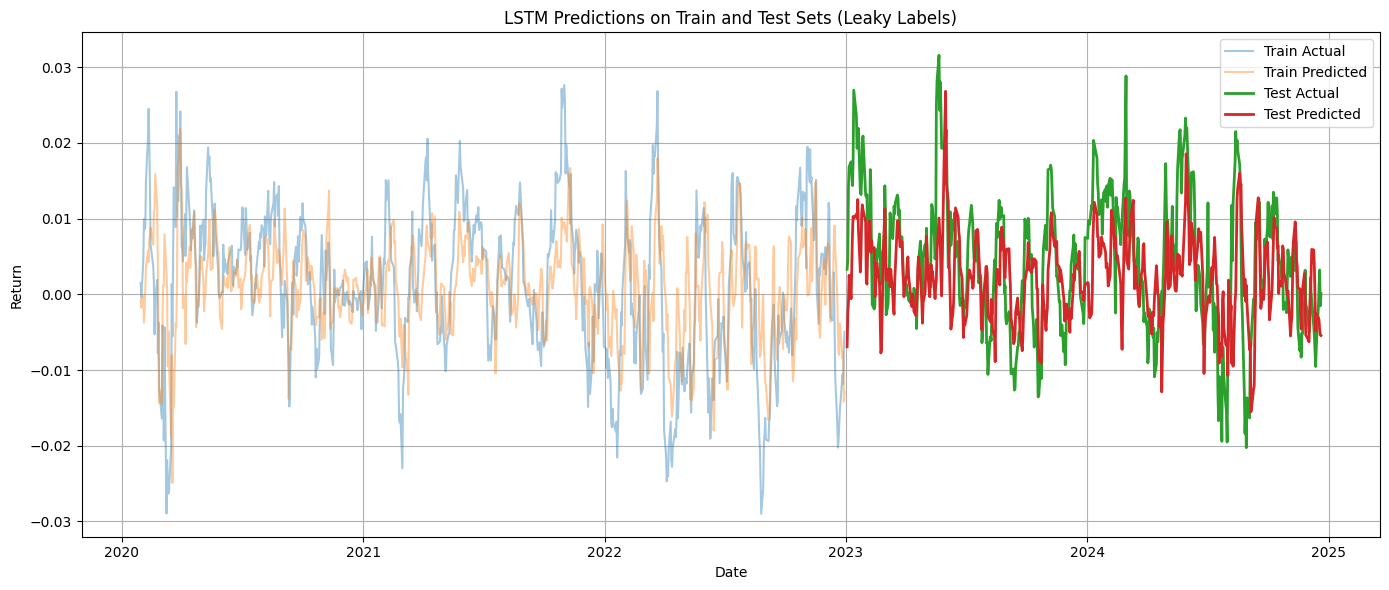

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Prepare sequential data
# -----------------------------
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]
target_col = "leaky_label"

X_raw = data[feature_cols].values
y_raw = data[target_col].values
dates = data.index.values

seq_len = 10

X_seq, y_seq, date_seq = [], [], []

for i in range(seq_len, len(X_raw)):
    X_seq.append(X_raw[i - seq_len:i])
    y_seq.append(y_raw[i])
    date_seq.append(dates[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
date_seq = np.array(date_seq)

# -----------------------------
# Single time-based train/test split
# -----------------------------
split_date = np.datetime64("2023-01-01")

train_mask = date_seq < split_date
test_mask  = date_seq >= split_date

X_train, X_test = X_seq[train_mask], X_seq[test_mask]
y_train, y_test = y_seq[train_mask], y_seq[test_mask]
dates_train, dates_test = date_seq[train_mask], date_seq[test_mask]

# -----------------------------
# Build LSTM model
# -----------------------------
model = Sequential([
    LSTM(64, input_shape=(seq_len, X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# -----------------------------
# Train model
# -----------------------------
model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

# -----------------------------
# Predictions
# -----------------------------
train_pred = model.predict(X_train).flatten()
test_pred  = model.predict(X_test).flatten()

# -----------------------------
# Metrics: R² and MSE
# -----------------------------
train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)

train_mse = mean_squared_error(y_train, train_pred)
test_mse  = mean_squared_error(y_test, test_pred)

print("Train R²:", train_r2)
print("Test  R²:", test_r2)
print("Train MSE:", train_mse)
print("Test  MSE:", test_mse)

# -----------------------------
# Plot 1: Time series (Test set)
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label="Actual Leaky Label")
plt.plot(dates_test, test_pred, label="LSTM Prediction")
plt.title("NVDA Test Set: LSTM Prediction vs Actual (Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Predicted vs Actual scatter (Test set)
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("LSTM Predicted vs Actual Returns (Test Set)")
plt.xlabel("Actual Leaky Label")
plt.ylabel("Predicted Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Train vs Test comparison
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(dates_train, y_train, label="Train Actual", alpha=0.4)
plt.plot(dates_train, train_pred, label="Train Predicted", alpha=0.4)
plt.plot(dates_test, y_test, label="Test Actual", linewidth=2)
plt.plot(dates_test, test_pred, label="Test Predicted", linewidth=2)
plt.title("LSTM Predictions on Train and Test Sets (Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0117 - val_loss: 6.6776e-04
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - val_loss: 2.7555e-04
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.2051e-04 - val_loss: 5.0827e-04
Epoch 4/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.5566e-04 - val_loss: 1.2407e-04
Epoch 5/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5200e-04 - val_loss: 1.1759e-04
Epoch 6/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1822e-04 - val_loss: 1.1701e-04
Epoch 7/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1849e-04 - val_loss: 1.1710e-04
Epoch 8/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1411e-04 - val_loss: 1.1738e-04
Epoch 9/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.1535e-04 - val_loss: 1.1741e-04
Epoch 10/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.1344e-04 - val_loss: 1.1673e-04
Epoch 11/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1107e-04 - val_

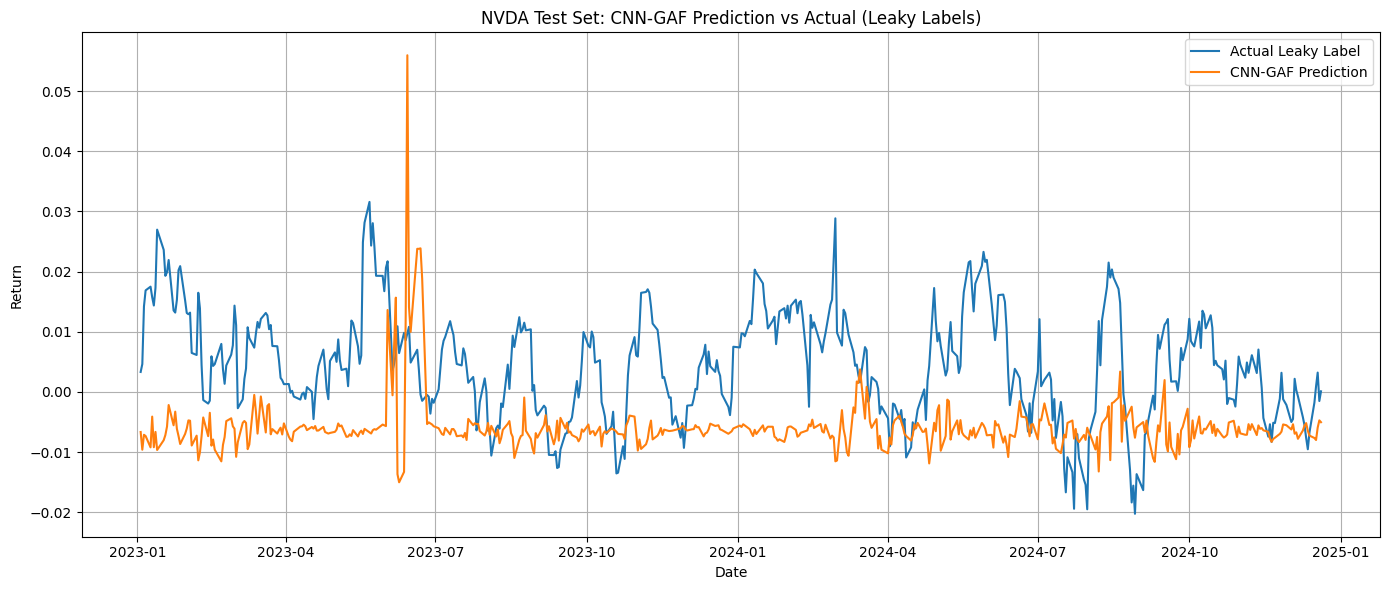

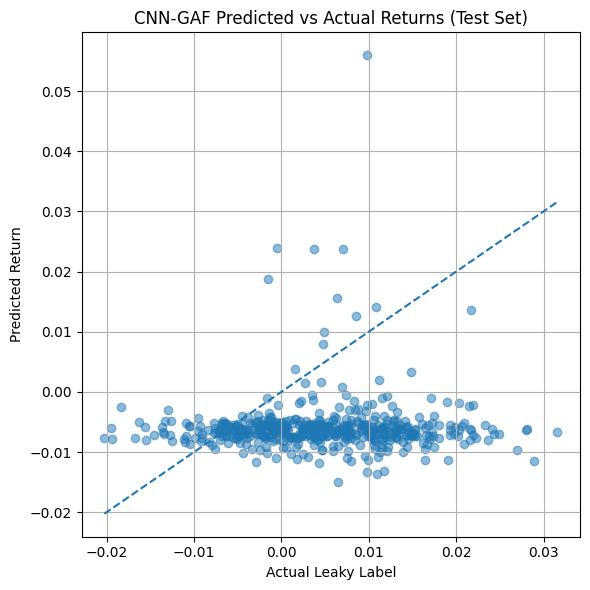

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------
# Prepare raw features and labels
# -------------------------------------------------
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]
target_col = "leaky_label"

X_raw = data[feature_cols].values
y_raw = data[target_col].values
dates = data.index.values

# -------------------------------------------------
# Scale features to [-1, 1] for GAF
# -------------------------------------------------
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_raw)

# -------------------------------------------------
# Gramian Angular Field function
# -------------------------------------------------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

# -------------------------------------------------
# Build multi-channel GAF images
# -------------------------------------------------
window_size = 16

X_gaf = []
y_seq = []
date_seq = []

for i in range(window_size, len(X_scaled)):
    gaf_channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        gaf_channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(gaf_channels, axis=-1))
    y_seq.append(y_raw[i])
    date_seq.append(dates[i])

X_gaf = np.array(X_gaf)
y_seq = np.array(y_seq)
date_seq = np.array(date_seq)

# -------------------------------------------------
# Single time-based train/test split
# -------------------------------------------------
split_date = np.datetime64("2023-01-01")

train_mask = date_seq < split_date
test_mask  = date_seq >= split_date

X_train, X_test = X_gaf[train_mask], X_gaf[test_mask]
y_train, y_test = y_seq[train_mask], y_seq[test_mask]
dates_train, dates_test = date_seq[train_mask], date_seq[test_mask]

# -------------------------------------------------
# Build CNN model
# -------------------------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=X_train.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# -------------------------------------------------
# Train model
# -------------------------------------------------
model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

# -------------------------------------------------
# Predictions
# -------------------------------------------------
train_pred = model.predict(X_train).flatten()
test_pred  = model.predict(X_test).flatten()

# -------------------------------------------------
# Metrics
# -------------------------------------------------
train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)
train_mse = mean_squared_error(y_train, train_pred)
test_mse  = mean_squared_error(y_test, test_pred)

print("Train R²:", train_r2)
print("Test  R²:", test_r2)
print("Train MSE:", train_mse)
print("Test  MSE:", test_mse)

# -------------------------------------------------
# Plot 1: Time series (Test set)
# -------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label="Actual Leaky Label")
plt.plot(dates_test, test_pred, label="CNN-GAF Prediction")
plt.title("NVDA Test Set: CNN-GAF Prediction vs Actual (Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot 2: Predicted vs Actual scatter
# -------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("CNN-GAF Predicted vs Actual Returns (Test Set)")
plt.xlabel("Actual Leaky Label")
plt.ylabel("Predicted Return")
plt.grid(True)
plt.tight_layout()
plt.show()



##Step 2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
                   MLP      LSTM   CNN-GAF
Total Return -0.750232 -0.231142  0.217991
Sharpe Ratio -0.973701  0.038300  0.453278
Max Drawdown -0.795552 -0.717062 -0.721082


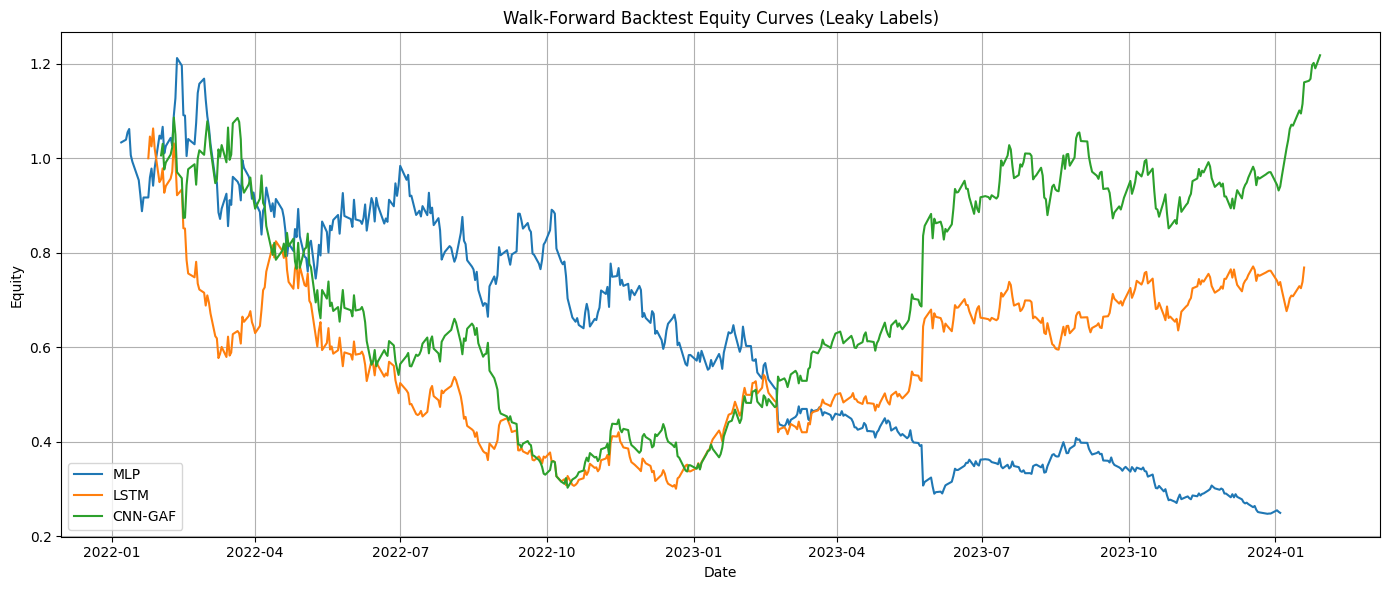

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

# =========================================================
# 0. Common settings
# =========================================================
train_size = 500
test_size = 500
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]

returns = data["log_return"]

# =========================================================
# 1. Build feature matrices
# =========================================================

# -------- MLP (2D) --------
X_mlp = data[feature_cols].values
y_mlp = data["leaky_label"].values
returns_mlp = returns

# -------- LSTM (3D sequence) --------
seq_len = 10

X_lstm, y_lstm, returns_lstm = [], [], []

X_raw = X_mlp
y_raw = y_mlp

for i in range(seq_len, len(X_raw)):
    X_lstm.append(X_raw[i - seq_len:i])
    y_lstm.append(y_raw[i])
    returns_lstm.append(returns.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
returns_lstm = pd.Series(returns_lstm, index=data.index[seq_len:])

# -------- CNN-GAF (4D image) --------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_raw)

window_size = 16
X_gaf, y_gaf, returns_gaf = [], [], []

for i in range(window_size, len(X_scaled)):
    channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(channels, axis=-1))
    y_gaf.append(y_raw[i])
    returns_gaf.append(returns.iloc[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)
returns_gaf = pd.Series(returns_gaf, index=data.index[window_size:])

# =========================================================
# 2. Model builders
# =========================================================
def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32),
                             max_iter=1000,
                             random_state=42))
    ])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

# =========================================================
# 3. Walk-forward backtest engine (non-anchored)
# =========================================================
def walk_forward_backtest(X, y, returns, model_type):
    strategy_returns = []
    idx = returns.index
    start = 0

    while start + train_size + test_size <= len(X):
        tr_slice = slice(start, start + train_size)
        te_slice = slice(start + train_size, start + train_size + test_size)

        X_train, X_test = X[tr_slice], X[te_slice]
        y_train, y_test = y[tr_slice], y[te_slice]
        ret_test = returns.iloc[te_slice]

        if model_type == "mlp":
            model = build_mlp()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        elif model_type == "lstm":
            model = build_lstm((X.shape[1], X.shape[2]))
            model.fit(X_train, y_train,
                      epochs=20, batch_size=32,
                      shuffle=False, verbose=0)
            preds = model.predict(X_test).flatten()

        elif model_type == "cnn":
            model = build_cnn(X.shape[1:])
            model.fit(X_train, y_train,
                      epochs=20, batch_size=32,
                      shuffle=False, verbose=0)
            preds = model.predict(X_test).flatten()

        signals = np.sign(preds)
        strat_ret = signals * ret_test.values

        strategy_returns.extend(strat_ret)
        start += test_size

    return pd.Series(strategy_returns, index=idx[train_size:train_size+len(strategy_returns)])

# =========================================================
# 4. Run backtests
# =========================================================
mlp_returns  = walk_forward_backtest(X_mlp,  y_mlp,  returns_mlp,  "mlp")
lstm_returns = walk_forward_backtest(X_lstm, y_lstm, returns_lstm, "lstm")
cnn_returns  = walk_forward_backtest(X_gaf,  y_gaf,  returns_gaf,  "cnn")

# =========================================================
# 5. Performance summary
# =========================================================
def summarize(returns):
    equity = (1 + returns).cumprod()
    total_return = equity.iloc[-1] - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    max_dd = (equity / equity.cummax() - 1).min()
    return total_return, sharpe, max_dd

summary = pd.DataFrame({
    "MLP": summarize(mlp_returns),
    "LSTM": summarize(lstm_returns),
    "CNN-GAF": summarize(cnn_returns)
}, index=["Total Return", "Sharpe Ratio", "Max Drawdown"])

print(summary)

# =========================================================
# 6. Plot equity curves
# =========================================================
plt.figure(figsize=(14,6))
plt.plot((1+mlp_returns).cumprod(), label="MLP")
plt.plot((1+lstm_returns).cumprod(), label="LSTM")
plt.plot((1+cnn_returns).cumprod(), label="CNN-GAF")
plt.title("Walk-Forward Backtest Equity Curves (Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
                   MLP      LSTM   CNN-GAF
Total Return -0.620939 -0.581464 -0.647503
Sharpe Ratio -0.343130 -0.285816 -0.400012
Max Drawdown -0.859708 -0.807555 -0.767824


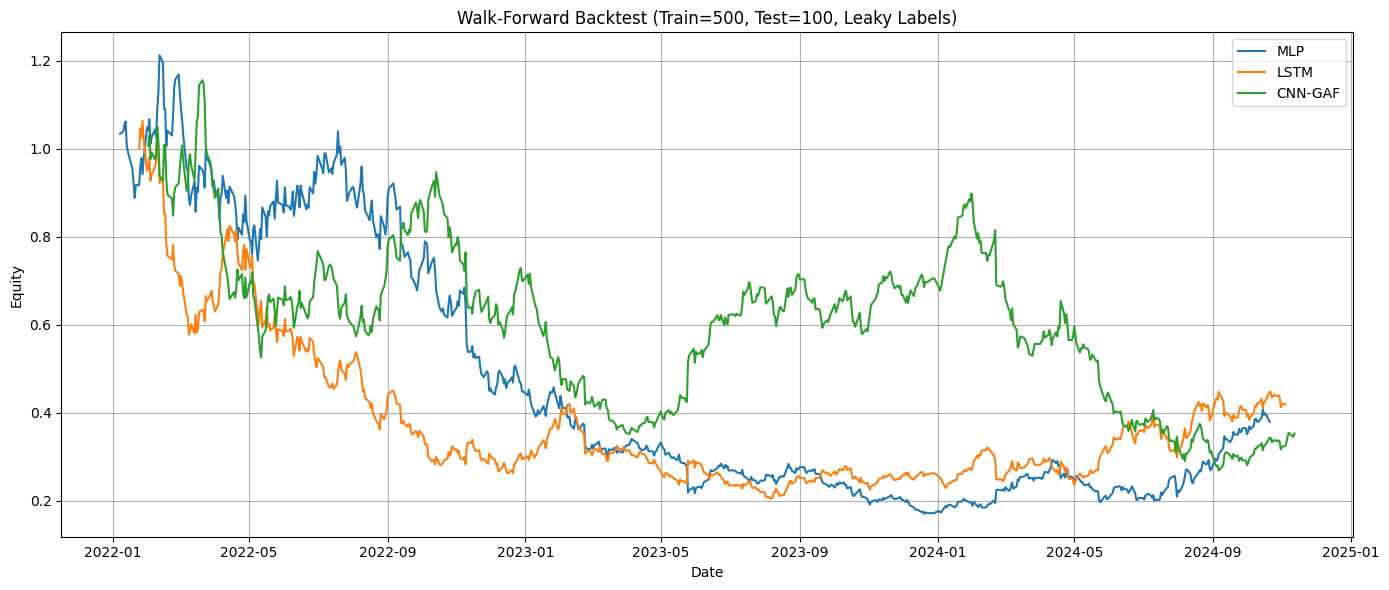

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

# =========================================================
# 0. Common settings
# =========================================================
train_size = 500
test_size = 100
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]

returns = data["log_return"]

# =========================================================
# 1. Build feature matrices
# =========================================================

# -------- MLP --------
X_mlp = data[feature_cols].values
y_mlp = data["leaky_label"].values
returns_mlp = returns

# -------- LSTM --------
seq_len = 10
X_lstm, y_lstm, returns_lstm = [], [], []

for i in range(seq_len, len(X_mlp)):
    X_lstm.append(X_mlp[i - seq_len:i])
    y_lstm.append(y_mlp[i])
    returns_lstm.append(returns.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
returns_lstm = pd.Series(returns_lstm, index=data.index[seq_len:])

# -------- CNN-GAF --------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_mlp)

window_size = 16
X_gaf, y_gaf, returns_gaf = [], [], []

for i in range(window_size, len(X_scaled)):
    channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(channels, axis=-1))
    y_gaf.append(y_mlp[i])
    returns_gaf.append(returns.iloc[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)
returns_gaf = pd.Series(returns_gaf, index=data.index[window_size:])

# =========================================================
# 2. Model builders
# =========================================================
def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32),
                             max_iter=1000,
                             random_state=42))
    ])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

# =========================================================
# 3. Walk-forward backtest engine (non-anchored)
# =========================================================
def walk_forward_backtest(X, y, returns, model_type):
    strategy_returns = []
    index_out = []
    start = 0

    while start + train_size + test_size <= len(X):

        tr = slice(start, start + train_size)
        te = slice(start + train_size, start + train_size + test_size)

        X_train, X_test = X[tr], X[te]
        y_train = y[tr]
        ret_test = returns.iloc[te]

        if model_type == "mlp":
            model = build_mlp()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        elif model_type == "lstm":
            model = build_lstm((X.shape[1], X.shape[2]))
            model.fit(X_train, y_train,
                      epochs=20, batch_size=32,
                      shuffle=False, verbose=0)
            preds = model.predict(X_test).flatten()

        elif model_type == "cnn":
            model = build_cnn(X.shape[1:])
            model.fit(X_train, y_train,
                      epochs=20, batch_size=32,
                      shuffle=False, verbose=0)
            preds = model.predict(X_test).flatten()

        signals = np.sign(preds)
        strat_ret = signals * ret_test.values

        strategy_returns.extend(strat_ret)
        index_out.extend(ret_test.index)

        start += test_size

    return pd.Series(strategy_returns, index=index_out)

# =========================================================
# 4. Run backtests
# =========================================================
mlp_returns  = walk_forward_backtest(X_mlp,  y_mlp,  returns_mlp,  "mlp")
lstm_returns = walk_forward_backtest(X_lstm, y_lstm, returns_lstm, "lstm")
cnn_returns  = walk_forward_backtest(X_gaf,  y_gaf,  returns_gaf,  "cnn")

# =========================================================
# 5. Performance summary
# =========================================================
def summarize(returns):
    equity = (1 + returns).cumprod()
    total_return = equity.iloc[-1] - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    max_dd = (equity / equity.cummax() - 1).min()
    return total_return, sharpe, max_dd

summary = pd.DataFrame({
    "MLP": summarize(mlp_returns),
    "LSTM": summarize(lstm_returns),
    "CNN-GAF": summarize(cnn_returns)
}, index=["Total Return", "Sharpe Ratio", "Max Drawdown"])

print(summary)

# =========================================================
# 6. Plot equity curves
# =========================================================
plt.figure(figsize=(14,6))
plt.plot((1+mlp_returns).cumprod(), label="MLP")
plt.plot((1+lstm_returns).cumprod(), label="LSTM")
plt.plot((1+cnn_returns).cumprod(), label="CNN-GAF")
plt.title("Walk-Forward Backtest (Train=500, Test=100, Leaky Labels)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##Step 3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
                   MLP      LSTM   CNN-GAF
Total Return -0.820641  0.455488 -0.586332
Sharpe Ratio -0.830571  0.518790 -0.300722
Max Drawdown -0.915839 -0.506418 -0.797398


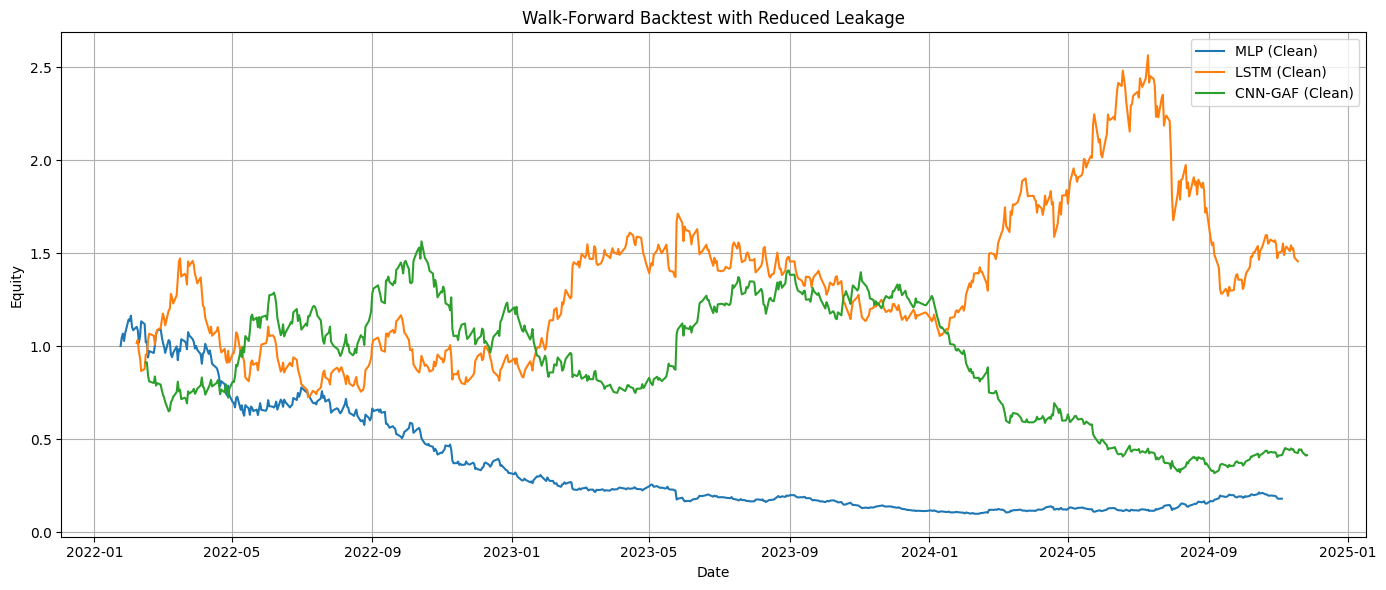

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

# =========================================================
# 0. Causal (clean) label construction
# =========================================================
data["clean_label"] = data["log_return"].shift(-1)
data = data.dropna()

# =========================================================
# 1. Feature matrices
# =========================================================
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]
returns = data["log_return"]

# -------- MLP --------
X_mlp = data[feature_cols].values
y_mlp = data["clean_label"].values
returns_mlp = returns

# -------- LSTM --------
seq_len = 10
X_lstm, y_lstm, returns_lstm = [], [], []

for i in range(seq_len, len(X_mlp)):
    X_lstm.append(X_mlp[i - seq_len:i])
    y_lstm.append(y_mlp[i])
    returns_lstm.append(returns.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
returns_lstm = pd.Series(returns_lstm, index=data.index[seq_len:])

# -------- CNN-GAF --------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_mlp)

window_size = 16
X_gaf, y_gaf, returns_gaf = [], [], []

for i in range(window_size, len(X_scaled)):
    channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(channels, axis=-1))
    y_gaf.append(y_mlp[i])
    returns_gaf.append(returns.iloc[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)
returns_gaf = pd.Series(returns_gaf, index=data.index[window_size:])

# =========================================================
# 2. Model builders
# =========================================================
def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

# =========================================================
# 3. Walk-forward backtest with purging and embargo
# =========================================================
def walk_forward_backtest_purged(
    X, y, returns, model_type,
    train_size=500,
    test_size=100,
    purge_size=10,
    embargo_size=10
):
    strategy_returns = []
    index_out = []
    start = 0

    while start + train_size + purge_size + test_size + embargo_size <= len(X):

        train_start = start
        train_end = start + train_size - purge_size
        test_start = start + train_size + purge_size
        test_end = test_start + test_size

        X_train = X[train_start:train_end]
        y_train = y[train_start:train_end]
        X_test = X[test_start:test_end]
        ret_test = returns.iloc[test_start:test_end]

        if model_type == "mlp":
            model = build_mlp()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        elif model_type == "lstm":
            model = build_lstm((X.shape[1], X.shape[2]))
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        elif model_type == "cnn":
            model = build_cnn(X.shape[1:])
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        signals = np.sign(preds)
        strat_ret = signals * ret_test.values

        strategy_returns.extend(strat_ret)
        index_out.extend(ret_test.index)

        start += test_size

    return pd.Series(strategy_returns, index=index_out)

# =========================================================
# 4. Run leakage-reduced backtests
# =========================================================
mlp_clean = walk_forward_backtest_purged(X_mlp, y_mlp, returns_mlp, "mlp")
lstm_clean = walk_forward_backtest_purged(X_lstm, y_lstm, returns_lstm, "lstm")
cnn_clean = walk_forward_backtest_purged(X_gaf, y_gaf, returns_gaf, "cnn")

# =========================================================
# 5. Performance summary
# =========================================================
def summarize(returns):
    equity = (1 + returns).cumprod()
    total_return = equity.iloc[-1] - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    max_dd = (equity / equity.cummax() - 1).min()
    return total_return, sharpe, max_dd

summary_clean = pd.DataFrame({
    "MLP": summarize(mlp_clean),
    "LSTM": summarize(lstm_clean),
    "CNN-GAF": summarize(cnn_clean)
}, index=["Total Return", "Sharpe Ratio", "Max Drawdown"])

print(summary_clean)

# =========================================================
# 6. Plot equity curves
# =========================================================
plt.figure(figsize=(14, 6))
plt.plot((1 + mlp_clean).cumprod(), label="MLP (Clean)")
plt.plot((1 + lstm_clean).cumprod(), label="LSTM (Clean)")
plt.plot((1 + cnn_clean).cumprod(), label="CNN-GAF (Clean)")
plt.title("Walk-Forward Backtest with Reduced Leakage")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
                   MLP      LSTM   CNN-GAF
Total Return -0.754951  2.174459  2.136078
Sharpe Ratio -0.992458  1.329780  1.322587
Max Drawdown -0.789318 -0.620810 -0.349662


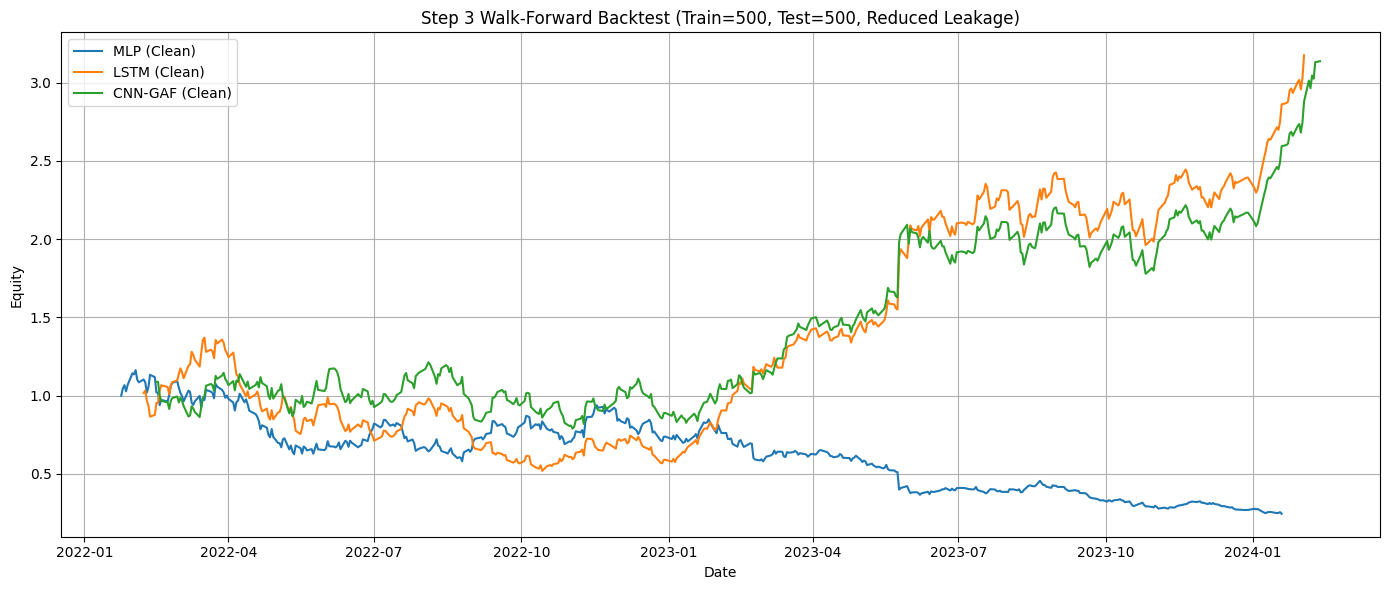

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

# =========================================================
# 0. Clean (causal) label to reduce leakage
# =========================================================
data["clean_label"] = data["log_return"].shift(-1)
data = data.dropna()

# =========================================================
# 1. Feature matrices
# =========================================================
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]
returns = data["log_return"]

# -------- MLP --------
X_mlp = data[feature_cols].values
y_mlp = data["clean_label"].values
returns_mlp = returns

# -------- LSTM --------
seq_len = 10
X_lstm, y_lstm, returns_lstm = [], [], []

for i in range(seq_len, len(X_mlp)):
    X_lstm.append(X_mlp[i - seq_len:i])
    y_lstm.append(y_mlp[i])
    returns_lstm.append(returns.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
returns_lstm = pd.Series(returns_lstm, index=data.index[seq_len:])

# -------- CNN-GAF --------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_mlp)

window_size = 16
X_gaf, y_gaf, returns_gaf = [], [], []

for i in range(window_size, len(X_scaled)):
    channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(channels, axis=-1))
    y_gaf.append(y_mlp[i])
    returns_gaf.append(returns.iloc[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)
returns_gaf = pd.Series(returns_gaf, index=data.index[window_size:])

# =========================================================
# 2. Model builders
# =========================================================
def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

# =========================================================
# 3. Walk-forward backtest with purging and embargo
# =========================================================
def walk_forward_backtest_purged(
    X, y, returns, model_type,
    train_size=500,
    test_size=500,
    purge_size=10,
    embargo_size=10
):
    strategy_returns = []
    index_out = []
    start = 0

    while start + train_size + purge_size + test_size + embargo_size <= len(X):

        train_start = start
        train_end = start + train_size - purge_size
        test_start = start + train_size + purge_size
        test_end = test_start + test_size

        X_train = X[train_start:train_end]
        y_train = y[train_start:train_end]
        X_test = X[test_start:test_end]
        ret_test = returns.iloc[test_start:test_end]

        if model_type == "mlp":
            model = build_mlp()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        elif model_type == "lstm":
            model = build_lstm((X.shape[1], X.shape[2]))
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        elif model_type == "cnn":
            model = build_cnn(X.shape[1:])
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        signals = np.sign(preds)
        strat_ret = signals * ret_test.values

        strategy_returns.extend(strat_ret)
        index_out.extend(ret_test.index)

        start += test_size

    return pd.Series(strategy_returns, index=index_out)

# =========================================================
# 4. Run clean walk-forward backtests (Train=500, Test=500)
# =========================================================
mlp_clean  = walk_forward_backtest_purged(X_mlp,  y_mlp,  returns_mlp,  "mlp")
lstm_clean = walk_forward_backtest_purged(X_lstm, y_lstm, returns_lstm, "lstm")
cnn_clean  = walk_forward_backtest_purged(X_gaf,  y_gaf,  returns_gaf,  "cnn")

# =========================================================
# 5. Performance summary
# =========================================================
def summarize(returns):
    equity = (1 + returns).cumprod()
    total_return = equity.iloc[-1] - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    max_dd = (equity / equity.cummax() - 1).min()
    return total_return, sharpe, max_dd

summary_step3 = pd.DataFrame({
    "MLP": summarize(mlp_clean),
    "LSTM": summarize(lstm_clean),
    "CNN-GAF": summarize(cnn_clean)
}, index=["Total Return", "Sharpe Ratio", "Max Drawdown"])

print(summary_step3)

# =========================================================
# 6. Equity curve plot
# =========================================================
plt.figure(figsize=(14,6))
plt.plot((1 + mlp_clean).cumprod(), label="MLP (Clean)")
plt.plot((1 + lstm_clean).cumprod(), label="LSTM (Clean)")
plt.plot((1 + cnn_clean).cumprod(), label="CNN-GAF (Clean)")
plt.title("Step 3 Walk-Forward Backtest (Train=500, Test=500, Reduced Leakage)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
                   MLP      LSTM   CNN-GAF
Total Return -0.820641  0.387946  0.408665
Sharpe Ratio -0.830571  0.488905  0.498936
Max Drawdown -0.915839 -0.504858 -0.559681


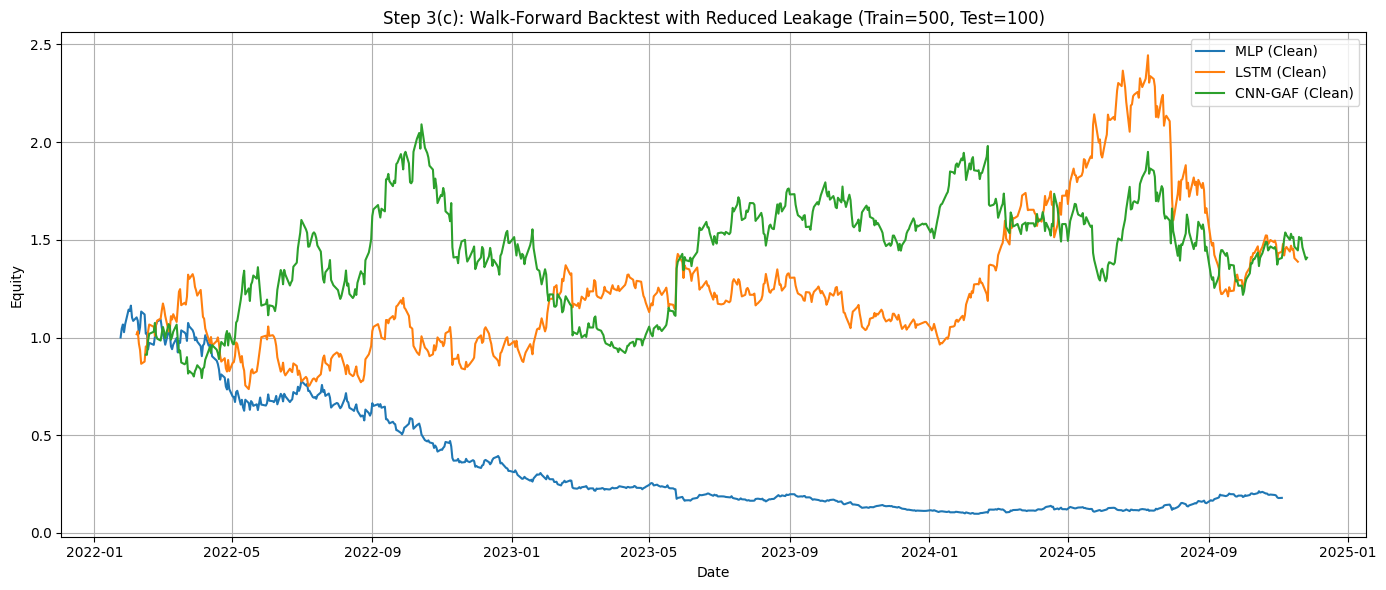

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

# =========================================================
# 0. Leakage reduction: causal label
# =========================================================
# One-step-ahead return (no overlapping future information)
data["clean_label"] = data["log_return"].shift(-1)
data = data.dropna()

# =========================================================
# 1. Feature matrices
# =========================================================
feature_cols = ["ret_lag1", "ret_lag2", "ret_lag3"]
returns = data["log_return"]

# -------- MLP --------
X_mlp = data[feature_cols].values
y_mlp = data["clean_label"].values
returns_mlp = returns

# -------- LSTM --------
seq_len = 10
X_lstm, y_lstm, returns_lstm = [], [], []

for i in range(seq_len, len(X_mlp)):
    X_lstm.append(X_mlp[i - seq_len:i])
    y_lstm.append(y_mlp[i])
    returns_lstm.append(returns.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
returns_lstm = pd.Series(returns_lstm, index=data.index[seq_len:])

# -------- CNN-GAF --------
def gramian_angular_field(ts):
    ts = np.clip(ts, -1, 1)
    phi = np.arccos(ts)
    return np.cos(phi[:, None] + phi[None, :])

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_mlp)

window_size = 16
X_gaf, y_gaf, returns_gaf = [], [], []

for i in range(window_size, len(X_scaled)):
    channels = []
    for j in range(X_scaled.shape[1]):
        ts_window = X_scaled[i - window_size:i, j]
        channels.append(gramian_angular_field(ts_window))
    X_gaf.append(np.stack(channels, axis=-1))
    y_gaf.append(y_mlp[i])
    returns_gaf.append(returns.iloc[i])

X_gaf = np.array(X_gaf)
y_gaf = np.array(y_gaf)
returns_gaf = pd.Series(returns_gaf, index=data.index[window_size:])

# =========================================================
# 2. Model builders
# =========================================================
def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

# =========================================================
# 3. Walk-forward backtest with purging and embargo
# =========================================================
def walk_forward_backtest_purged(
    X, y, returns, model_type,
    train_size=500,
    test_size=100,
    purge_size=10,
    embargo_size=10
):
    strategy_returns = []
    index_out = []
    start = 0

    while start + train_size + purge_size + test_size + embargo_size <= len(X):

        train_start = start
        train_end = start + train_size - purge_size
        test_start = start + train_size + purge_size
        test_end = test_start + test_size

        X_train = X[train_start:train_end]
        y_train = y[train_start:train_end]
        X_test = X[test_start:test_end]
        ret_test = returns.iloc[test_start:test_end]

        if model_type == "mlp":
            model = build_mlp()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        elif model_type == "lstm":
            model = build_lstm((X.shape[1], X.shape[2]))
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        elif model_type == "cnn":
            model = build_cnn(X.shape[1:])
            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                shuffle=False,
                verbose=0
            )
            preds = model.predict(X_test).flatten()

        signals = np.sign(preds)
        strat_ret = signals * ret_test.values

        strategy_returns.extend(strat_ret)
        index_out.extend(ret_test.index)

        start += test_size  # non-anchored rolling

    return pd.Series(strategy_returns, index=index_out)

# =========================================================
# 4. Run leakage-reduced walk-forward backtests
# =========================================================
mlp_clean_100  = walk_forward_backtest_purged(X_mlp,  y_mlp,  returns_mlp,  "mlp")
lstm_clean_100 = walk_forward_backtest_purged(X_lstm, y_lstm, returns_lstm, "lstm")
cnn_clean_100  = walk_forward_backtest_purged(X_gaf,  y_gaf,  returns_gaf,  "cnn")

# =========================================================
# 5. Performance summary
# =========================================================
def summarize(returns):
    equity = (1 + returns).cumprod()
    total_return = equity.iloc[-1] - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    max_dd = (equity / equity.cummax() - 1).min()
    return total_return, sharpe, max_dd

summary_step3c = pd.DataFrame({
    "MLP": summarize(mlp_clean_100),
    "LSTM": summarize(lstm_clean_100),
    "CNN-GAF": summarize(cnn_clean_100)
}, index=["Total Return", "Sharpe Ratio", "Max Drawdown"])

print(summary_step3c)

# =========================================================
# 6. Plot equity curves
# =========================================================
plt.figure(figsize=(14,6))
plt.plot((1 + mlp_clean_100).cumprod(), label="MLP (Clean)")
plt.plot((1 + lstm_clean_100).cumprod(), label="LSTM (Clean)")
plt.plot((1 + cnn_clean_100).cumprod(), label="CNN-GAF (Clean)")
plt.title("Step 3(c): Walk-Forward Backtest with Reduced Leakage (Train=500, Test=100)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
